In [1]:
import numpy as np

from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64

from IPython import get_ipython

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic(
        "config", "InlineBackend.rc = {'figure.dpi': 300}"
    )  # choose a value you like

# Kernels

In [2]:
# ohmic kernel
import numpy as np
from scipy.special import gammaln


# P(E) ohmic kernel
def get_Pohmic_meV(
    Eenv_meV: NDArray64,
    R_kOhm: float,
    nuc_GHz: float,
    q: int = 1,
):
    """
    Zero-temperature Ohmic P(E) cutoff model.

    Parameters
    ----------
    E_meV : float or array
        Exchanged energy in meV.
    R_kOhm : float
        Ohmic environmental resistance in kOhm.
    nuc_GHz : float
        Cutoff frequency nu_c in GHz. Uses E_c = h nu_c.
    q : int
        number of transported charges

    Returns
    -------
    P : float or array
        P(E) in 1/meV.
    """
    E = np.asarray(Eenv_meV, dtype=float)
    dE = E[1] - E[0]

    if R_kOhm == 0.0:
        P = np.zeros_like(E)
        i0 = np.argmin(np.abs(E))
        P[i0] = 1.0 / dE
    else:
        Ec = sc.h_pVs * nuc_GHz
        alpha = R_kOhm * sc.G0_muS * 1e-3 * q**2

        P = np.zeros_like(E, dtype=float)
        mask = E > 0

        # P(E) = 1/(Ec Gamma(alpha)) * (E/Ec)^(alpha-1) * exp(-E/Ec)
        x = E[mask] / Ec
        logP = -np.log(Ec) - gammaln(alpha) + (alpha - 1.0) * np.log(x) - x
        P[mask] = np.exp(logP)

    P /= np.trapezoid(P, E)
    if np.isscalar(Eenv_meV):
        return float(P)

    return P

In [3]:
# resonant kernel
import numpy as np
from scipy.special import gammaln


def get_Presonant_meV(
    Eenv_meV,
    R_kOhm,
    nuc_GHz,
    nu0_GHz,
    alpha0,
    nmax=None,
    q: int = 1,
):
    """
    Zero-temperature Ohmic P(E) with one harmonic environmental resonance.

    Model:
        P_res(E) = exp(-alpha0) sum_n alpha0^n/n! P_ohmic(E - n h nu0)

    Parameters
    ----------
    Eenv_meV : array
        Energy axis in meV.
    R_kOhm : float
        Ohmic background resistance in kOhm.
    nuc_GHz : float
        Ohmic cutoff frequency nu_c in GHz.
    nu0_GHz : float
        Resonance frequency nu_0 in GHz.
    alpha0 : float
        Dimensionless coupling strength to the resonant mode.
    nmax : int or None
        Maximum number of emitted mode quanta. If None, chosen automatically.
    q : int
        number of transported charges

    Returns
    -------
    P : array
        Resonant P(E) in 1/meV, normalized on the provided grid.
    """
    E = np.asarray(Eenv_meV, dtype=float)
    dE = E[1] - E[0]

    Ec = sc.h_pVs * nuc_GHz
    E0 = sc.h_pVs * nu0_GHz
    alpha = R_kOhm * sc.G0_muS * 1e-3 * q**2

    if nmax is None:
        nmax = int(np.ceil(alpha0 + 10.0 * np.sqrt(alpha0 + 1.0) + 10.0))

    def P_ohmic_raw(Eshift):
        if R_kOhm == 0.0:
            P = np.zeros_like(Eshift, dtype=float)
            i0 = np.argmin(np.abs(Eshift))
            P[i0] = 1.0 / dE
            return P

        P = np.zeros_like(Eshift, dtype=float)
        mask = Eshift > 0.0
        x = Eshift[mask] / Ec

        logP = -np.log(Ec) - gammaln(alpha) + (alpha - 1.0) * np.log(x) - x
        P[mask] = np.exp(logP)
        return P

    P = np.zeros_like(E, dtype=float)

    for n in range(nmax + 1):
        logw = (
            -alpha0 + n * np.log(alpha0) - gammaln(n + 1)
            if alpha0 > 0
            else (0.0 if n == 0 else -np.inf)
        )
        w = np.exp(logw)
        if w == 0.0:
            continue

        P += w * P_ohmic_raw(E - n * E0)

    norm = np.trapezoid(P, E)
    if norm > 0:
        P /= norm

    return P

In [4]:
# A12, A21 Kernel
def get_A_meV(
    E_meV: NDArray64,
    T1_K: float,
    T2_K: float,
    Delta1_meV: float,
    Delta2_meV: float,
    gamma1_meV: float,
    gamma2_meV: float,
):
    dE_meV = float(E_meV[1] - E_meV[0])
    DeltaT1_meV = sc.get_DeltaT_meV(Delta1_meV, T1_K)
    DeltaT2_meV = sc.get_DeltaT_meV(Delta2_meV, T2_K)
    dos1 = sc.get_dos(E_meV, DeltaT1_meV, gamma1_meV)
    dos2 = sc.get_dos(E_meV, DeltaT2_meV, gamma2_meV)
    occupied1 = dos1 * sc.get_f(E_meV, T1_K)
    occupied2 = dos2 * sc.get_f(E_meV, T2_K)
    empty1 = dos1 * (1.0 - sc.get_f(E_meV, T1_K))
    empty2 = dos2 * (1.0 - sc.get_f(E_meV, T2_K))
    A12_meV = np.correlate(empty2, occupied1, mode="full") * dE_meV
    A21_meV = np.correlate(empty1, occupied2, mode="full") * dE_meV
    E0_meV = np.arange(-(E_meV.size - 1), E_meV.size, dtype=np.float64) * dE_meV
    return A12_meV, A21_meV, E0_meV

In [5]:
# DCB I(V) Kernel
def dcb_current_np(
    V_mV: NDArray64,
    E0_meV: NDArray64,
    A12_meV: NDArray64,
    A21_meV: NDArray64,
    Eenv_meV: NDArray64,
    Penv_meV: NDArray64,
):
    V_mV = np.asarray(V_mV, dtype=np.float64)
    E0_meV = np.asarray(E0_meV, dtype=np.float64)
    A12_meV = np.asarray(A12_meV, dtype=np.float64)
    A21_meV = np.asarray(A21_meV, dtype=np.float64)
    Penv_meV = np.asarray(Penv_meV, dtype=np.float64)
    Eenv_meV = np.asarray(Eenv_meV, dtype=np.float64)

    Gamma12 = np.zeros_like(V_mV)
    Gamma21 = np.zeros_like(V_mV)

    for i, v_mV in enumerate(V_mV):
        U12env_meV = -Eenv_meV + v_mV
        U21env_meV = -Eenv_meV - v_mV

        A12env_meV = np.interp(x=U12env_meV, xp=E0_meV, fp=A12_meV, left=0.0, right=0.0)
        A21env_meV = np.interp(x=U21env_meV, xp=E0_meV, fp=A21_meV, left=0.0, right=0.0)

        Gamma12[i] = np.trapezoid(Penv_meV * A12env_meV, Eenv_meV)
        Gamma21[i] = np.trapezoid(Penv_meV * A21env_meV, Eenv_meV)

    return Gamma12 - Gamma21

# Calculation

In [6]:
# voltage def
Delta_meV = 0.18
V_Delta = np.linspace(0, 6, 501)
V_mV = V_Delta * Delta_meV
GN_G0 = 1.0

In [7]:
# P(E) Calculations
Rq_kOhm = 1e3 / sc.G0_muS

alphaq = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
R_kOhm = alphaq * Rq_kOhm / 2
R0_kOhm = 1.0 * Rq_kOhm / 2

nuc_GHz = Delta_meV / sc.h_pVs
nu0_GHz = 10.0

alpha0 = np.array([0.1, 0.5, 1.0, 2.0, 4.0])
alpha00 = 1.0

Eenv_Delta = np.linspace(0, 8, 5001)
Eenv_meV = Eenv_Delta * Delta_meV

Pohm_meV = np.zeros((R_kOhm.shape[0], Eenv_meV.shape[0]))
Pres_meV = np.zeros((R_kOhm.shape[0], Eenv_meV.shape[0]))

for i, r_kOhm in enumerate(R_kOhm):
    Pohm_meV[i, :] = get_Pohmic_meV(
        Eenv_meV=Eenv_meV,
        R_kOhm=r_kOhm,
        nuc_GHz=nuc_GHz,
    )
    Pres_meV[i, :] = get_Presonant_meV(
        Eenv_meV=Eenv_meV,
        R_kOhm=r_kOhm,
        nuc_GHz=nuc_GHz,
        nu0_GHz=nu0_GHz,
        alpha0=alpha00,
    )

Presa_meV = np.zeros((alpha0.shape[0], Eenv_meV.shape[0]))
for i, a0 in enumerate(alpha0):
    Presa_meV[i, :] = get_Presonant_meV(
        Eenv_meV=Eenv_meV,
        R_kOhm=R0_kOhm,
        nuc_GHz=nuc_GHz,
        nu0_GHz=nu0_GHz,
        alpha0=a0,
    )


# w(alpha)
n0 = np.arange(0, 15)
n1 = np.linspace(0, 15, 1001)

N0, Alpha0 = np.meshgrid(n0, alpha0)
N1, Alpha1 = np.meshgrid(n1, alpha0)

logw0 = -Alpha0 + N0 * np.log(Alpha0) - gammaln(N0 + 1)
logw1 = -Alpha1 + N1 * np.log(Alpha1) - gammaln(N1 + 1)

w0 = np.exp(logw0)
w1 = np.exp(logw1)

figsize = (1.35, 1.2)

In [8]:
# Tunnel Rates
T_K = 0.0
Delta_meV = 0.18
gamma_meV = 1e-7

# A12_meV, A21_meV
E_Delta = np.linspace(-6.0, 6.0, 150_001, dtype=np.float64)
E_meV = E_Delta * Delta_meV
A12sis_meV, A21sis_meV, E0_meV = get_A_meV(
    E_meV=E_meV,
    T1_K=T_K,
    T2_K=T_K,
    Delta1_meV=Delta_meV,
    Delta2_meV=Delta_meV,
    gamma1_meV=gamma_meV,
    gamma2_meV=gamma_meV,
)
A12sin_meV, A21sin_meV, E0_meV = get_A_meV(
    E_meV=E_meV,
    T1_K=T_K,
    T2_K=T_K,
    Delta1_meV=Delta_meV,
    Delta2_meV=0.0,
    gamma1_meV=gamma_meV,
    gamma2_meV=gamma_meV,
)
A12nin_meV, A21nin_meV, E0_meV = get_A_meV(
    E_meV=E_meV,
    T1_K=T_K,
    T2_K=T_K,
    Delta1_meV=0.0,
    Delta2_meV=0.0,
    gamma1_meV=gamma_meV,
    gamma2_meV=gamma_meV,
)

In [9]:
# Idcb_nA ohm
Isisohm_nA = np.zeros((R_kOhm.shape[0], V_mV.shape[0]))
Isinohm_nA = np.zeros((R_kOhm.shape[0], V_mV.shape[0]))
Ininohm_nA = np.zeros((R_kOhm.shape[0], V_mV.shape[0]))

for i, r_kOhm in enumerate(R_kOhm):
    Isisohm_nA[i, :] = (
        dcb_current_np(
            V_mV=V_mV,
            E0_meV=E0_meV,
            A12_meV=A12sis_meV,
            A21_meV=A21sis_meV,
            Penv_meV=Pohm_meV[i, :],
            Eenv_meV=Eenv_meV,
        )
        * GN_G0
        * sc.G0_muS
    )
    Isinohm_nA[i, :] = (
        dcb_current_np(
            V_mV=V_mV,
            E0_meV=E0_meV,
            A12_meV=A12sin_meV,
            A21_meV=A21sin_meV,
            Penv_meV=Pohm_meV[i, :],
            Eenv_meV=Eenv_meV,
        )
        * GN_G0
        * sc.G0_muS
    )
    Ininohm_nA[i, :] = (
        dcb_current_np(
            V_mV=V_mV,
            E0_meV=E0_meV,
            A12_meV=A12nin_meV,
            A21_meV=A21nin_meV,
            Penv_meV=Pohm_meV[i, :],
            Eenv_meV=Eenv_meV,
        )
        * GN_G0
        * sc.G0_muS
    )
dIdVsisohm = np.gradient(Isisohm_nA, V_mV, axis=1) / (GN_G0 * sc.G0_muS)
dIdVsinohm = np.gradient(Isinohm_nA, V_mV, axis=1) / (GN_G0 * sc.G0_muS)
dIdVninohm = np.gradient(Ininohm_nA, V_mV, axis=1) / (GN_G0 * sc.G0_muS)

In [10]:
# Idcb_nA res

Isisres_nA = np.zeros((R_kOhm.shape[0], V_mV.shape[0]))
Isinres_nA = np.zeros((R_kOhm.shape[0], V_mV.shape[0]))
Ininres_nA = np.zeros((R_kOhm.shape[0], V_mV.shape[0]))
for i, r_kOhm in enumerate(R_kOhm):
    Isisres_nA[i, :] = (
        dcb_current_np(
            V_mV=V_mV,
            E0_meV=E0_meV,
            A12_meV=A12sis_meV,
            A21_meV=A21sis_meV,
            Penv_meV=Pres_meV[i, :],
            Eenv_meV=Eenv_meV,
        )
        * GN_G0
        * sc.G0_muS
    )
    Isinres_nA[i, :] = (
        dcb_current_np(
            V_mV=V_mV,
            E0_meV=E0_meV,
            A12_meV=A12sin_meV,
            A21_meV=A21sin_meV,
            Penv_meV=Pres_meV[i, :],
            Eenv_meV=Eenv_meV,
        )
        * GN_G0
        * sc.G0_muS
    )
    Ininres_nA[i, :] = (
        dcb_current_np(
            V_mV=V_mV,
            E0_meV=E0_meV,
            A12_meV=A12nin_meV,
            A21_meV=A21nin_meV,
            Penv_meV=Pres_meV[i, :],
            Eenv_meV=Eenv_meV,
        )
        * GN_G0
        * sc.G0_muS
    )

dIdVsisres = np.gradient(Isisres_nA, V_mV, axis=1) / (GN_G0 * sc.G0_muS)
dIdVsinres = np.gradient(Isinres_nA, V_mV, axis=1) / (GN_G0 * sc.G0_muS)
dIdVninres = np.gradient(Ininres_nA, V_mV, axis=1) / (GN_G0 * sc.G0_muS)

In [11]:
# Idcb_nA res (alpha)

Isisresa_nA = np.zeros((alpha0.shape[0], V_mV.shape[0]))
Isinresa_nA = np.zeros((alpha0.shape[0], V_mV.shape[0]))
Ininresa_nA = np.zeros((alpha0.shape[0], V_mV.shape[0]))
for i, a0 in enumerate(alpha0):
    Isisresa_nA[i, :] = (
        dcb_current_np(
            V_mV=V_mV,
            E0_meV=E0_meV,
            A12_meV=A12sis_meV,
            A21_meV=A21sis_meV,
            Penv_meV=Presa_meV[i, :],
            Eenv_meV=Eenv_meV,
        )
        * GN_G0
        * sc.G0_muS
    )
    Isinresa_nA[i, :] = (
        dcb_current_np(
            V_mV=V_mV,
            E0_meV=E0_meV,
            A12_meV=A12sin_meV,
            A21_meV=A21sin_meV,
            Penv_meV=Presa_meV[i, :],
            Eenv_meV=Eenv_meV,
        )
        * GN_G0
        * sc.G0_muS
    )
    Ininresa_nA[i, :] = (
        dcb_current_np(
            V_mV=V_mV,
            E0_meV=E0_meV,
            A12_meV=A12nin_meV,
            A21_meV=A21nin_meV,
            Penv_meV=Presa_meV[i, :],
            Eenv_meV=Eenv_meV,
        )
        * GN_G0
        * sc.G0_muS
    )

dIdVsisresa = np.gradient(Isisresa_nA, V_mV, axis=1) / (GN_G0 * sc.G0_muS)
dIdVsinresa = np.gradient(Isinresa_nA, V_mV, axis=1) / (GN_G0 * sc.G0_muS)
dIdVninresa = np.gradient(Ininresa_nA, V_mV, axis=1) / (GN_G0 * sc.G0_muS)

In [12]:
# Ipat_nA
alphanu = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
alphanu0 = 1.0
nu_GHz = 10.0
A_mV = alphanu * nu_GHz * sc.h_pVs
A0_mV = alphanu0 * nu_GHz * sc.h_pVs

Ipat_nA = np.zeros((R_kOhm.shape[0], V_mV.shape[0]))
Ipata_nA = np.zeros((alphanu.shape[0], V_mV.shape[0]))

from superconductivity.models.bcs.backend.pat import pat_kernel

for i, r_kOhm in enumerate(R_kOhm):
    Ipat_nA[i, :] = pat_kernel(
        V_mV=V_mV,
        I_=Isisres_nA[i],
        A_mV=A0_mV,
        nu_GHz=nu_GHz,
    )

for i, alphanu_i in enumerate(alphanu):
    Ipata_nA[i, :] = pat_kernel(
        V_mV=V_mV,
        I_=Isisres_nA[1],
        A_mV=A_mV[i],
        nu_GHz=nu_GHz,
    )

dIdVpat = np.gradient(Ipat_nA, V_mV, axis=1) / (GN_G0 * sc.G0_muS)
dIdVpata = np.gradient(Ipata_nA, V_mV, axis=1) / (GN_G0 * sc.G0_muS)

In [13]:
figsize = (1.3, 1.2)

# P(E)

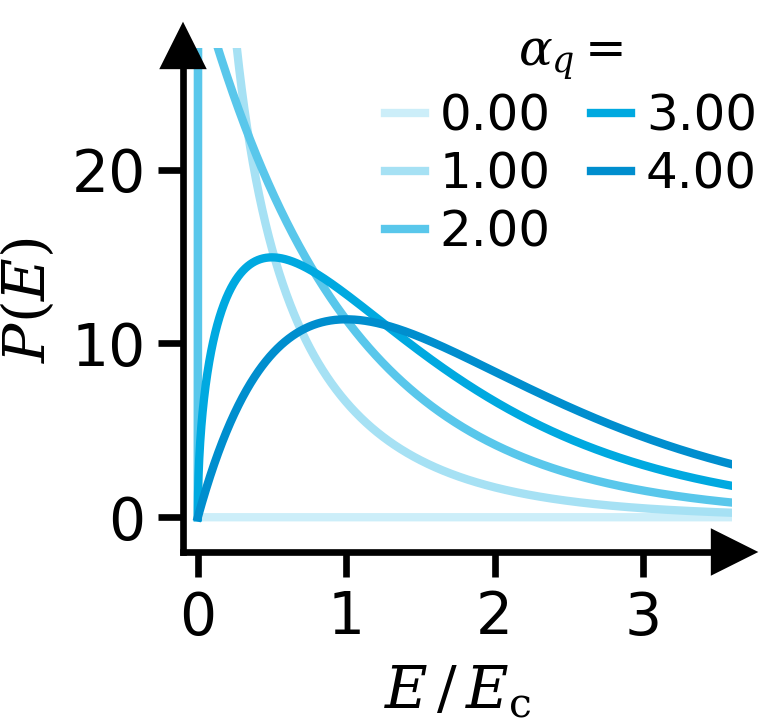

In [14]:
# P(E) Ohmic
fig, ax = sc.get_figure(figsize=figsize, padding=(0.225, 0.2))

for i, aq in enumerate(alphaq):
    ax.plot(
        Eenv_meV / (Delta_meV),
        Pohm_meV[i, :] / Delta_meV,
        color=sc.seeblau[4 - i],
        zorder=i,
        label=f"{aq:1.2f}",
    )

ax.legend(
    title="$\\alpha_q = $",
    handlelength=0.8,
    loc="upper right",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=2,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.2,  # reduces vertical spacing between items
    handletextpad=0.3,  # reduces spacing between line and label
    bbox_to_anchor=(1.1, 1.1),
)

ax.set_xlim(-0.1, 3.6)
ax.set_xticks([0, 1, 2, 3])

ax.set_ylim(-2, 27)

xlabel = "$E\\,/\\,E_\\mathrm{c}$"
ylabel = "$P(E)$"
title = "theory/stochastic/pe-ohm"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

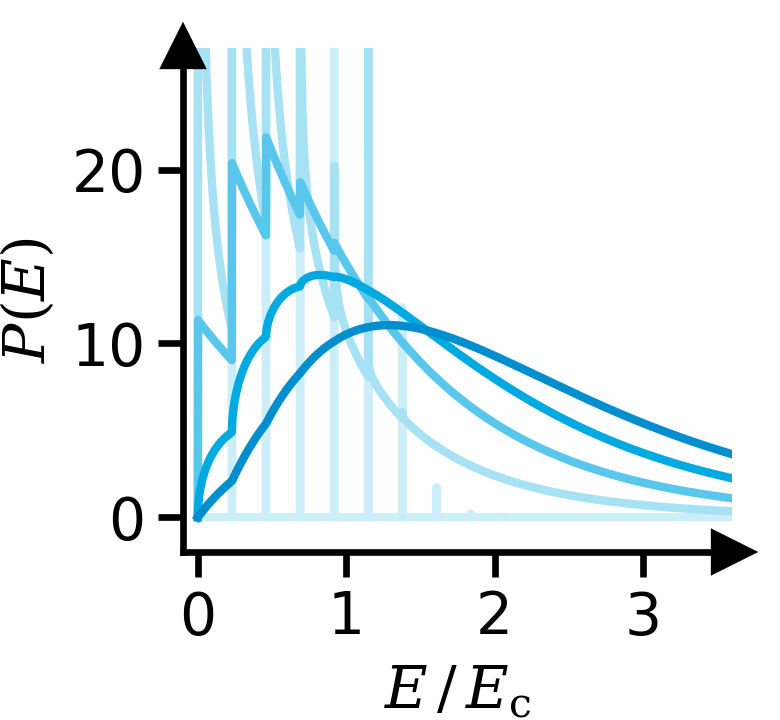

In [15]:
# P(E)
fig, ax = sc.get_figure(figsize=figsize, padding=(0.225, 0.2))

for i, aq in enumerate(alphaq):
    ax.plot(
        Eenv_meV / (Delta_meV),
        Pres_meV[i, :] / Delta_meV,
        color=sc.seeblau[4 - i],
        zorder=i,
        label=f"{aq:1.2f}",
    )

ax.set_xlim(-0.1, 3.6)
ax.set_xticks([0, 1, 2, 3])

ax.set_ylim(-2, 27)

xlabel = "$E\\,/\\,E_\\mathrm{c}$"
ylabel = "$P(E)$"
title = "theory/stochastic/pe-res"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

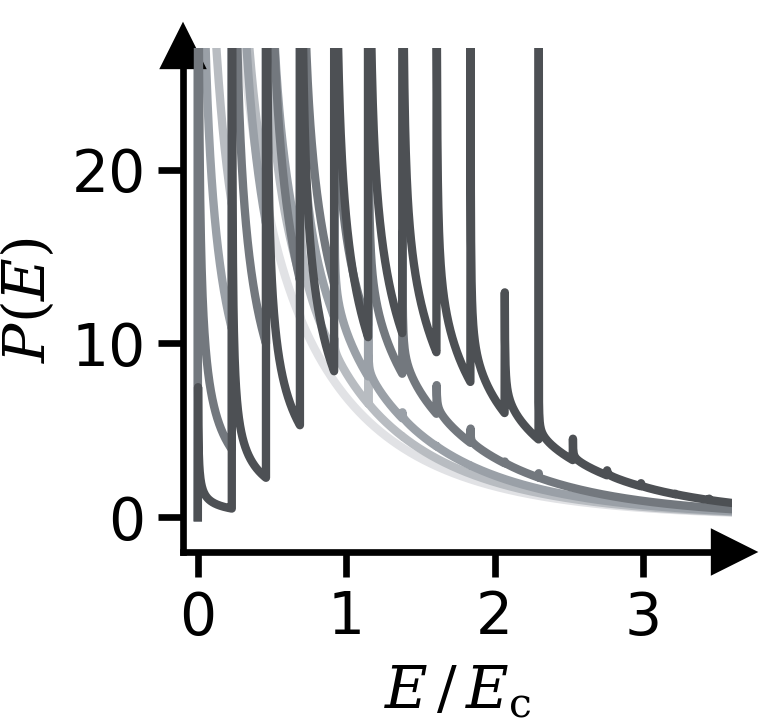

In [16]:
# P(E)
fig, ax = sc.get_figure(figsize=figsize, padding=(0.225, 0.2))

for i, aq in enumerate(alphaq):
    ax.plot(
        Eenv_meV / (Delta_meV),
        Presa_meV[i, :] / Delta_meV,
        color=sc.seegrau[4 - i],
        zorder=i,
        label=f"{aq:1.2f}",
    )

ax.set_xlim(-0.1, 3.6)
ax.set_xticks([0, 1, 2, 3])

ax.set_ylim(-2, 27)

xlabel = "$E\\,/\\,E_\\mathrm{c}$"
ylabel = "$P(E)$"
title = "theory/stochastic/pe-resa"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

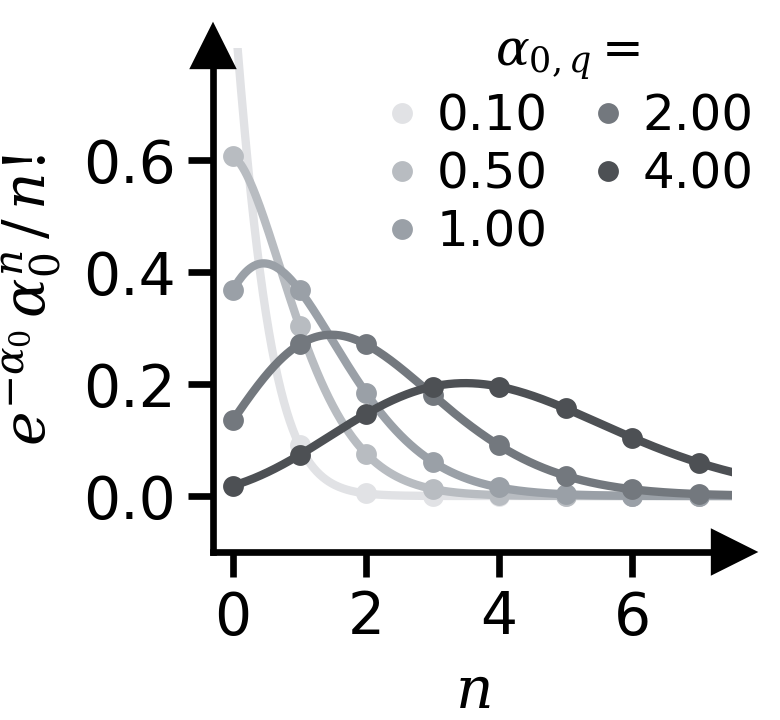

In [18]:
# P(E)-weights
fig, ax = sc.get_figure(figsize=figsize, padding=(0.275, 0.2))

for i, a in enumerate(alpha0):
    ax.plot(
        n0,
        w0[i, :],
        ".",
        ms=3,
        color=sc.seegrau[4 - i],
        zorder=i,
        label=f"{a:1.2f}",
    )
    ax.plot(
        n1,
        w1[i, :],
        color=sc.seegrau[4 - i],
        zorder=i,
    )

ax.legend(
    title="$\\alpha_{0, q} = $",
    handlelength=0.8,
    loc="upper right",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=2,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.2,  # reduces vertical spacing between items
    handletextpad=0.3,  # reduces spacing between line and label
    bbox_to_anchor=(1.1, 1.1),
)

ax.set_xlim(-0.3, 7.5)
ax.set_xticks([0, 2, 4, 6])

ax.set_ylim(-0.1, 0.8)
ax.set_yticks([0, 0.2, 0.4, 0.6])

xlabel = "$n$"
ylabel = "$e^{-\\alpha_0}\\,\\alpha_0^n\\,/\\,n!$"
title = "theory/stochastic/pe-res-w"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

# DCB

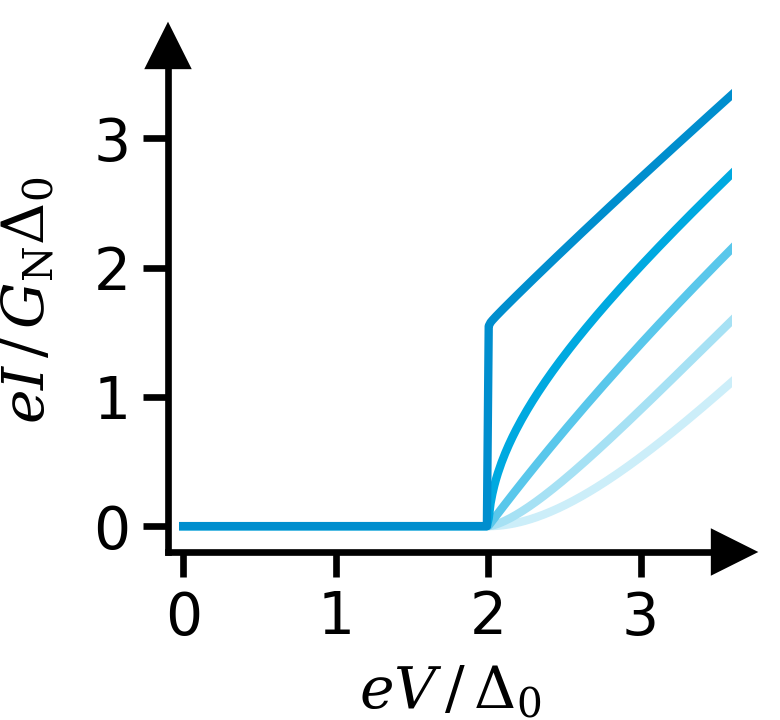

In [19]:
fig, ax = sc.get_figure(figsize=figsize)

for i, aq in enumerate(alphaq):
    ax.plot(
        V_Delta,
        Isisohm_nA[i, :] / (sc.G0_muS * Delta_meV),
        color=sc.seeblau[i],
        zorder=5 - i,
        label=f"{aq:1.2f}",
    )

ax.set_xlim(-0.1, 3.6)
ax.set_xticks([0, 1, 2, 3])

ax.set_ylim(-0.2, 3.7)
ax.set_yticks([0, 1, 2, 3])

xlabel = "$eV\\,/\\,\\Delta_0$"
ylabel = "$eI\\,/\\,G_\\mathrm{N}\\Delta_0$"
title = "theory/stochastic/dcb-ohm-iv-sis"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

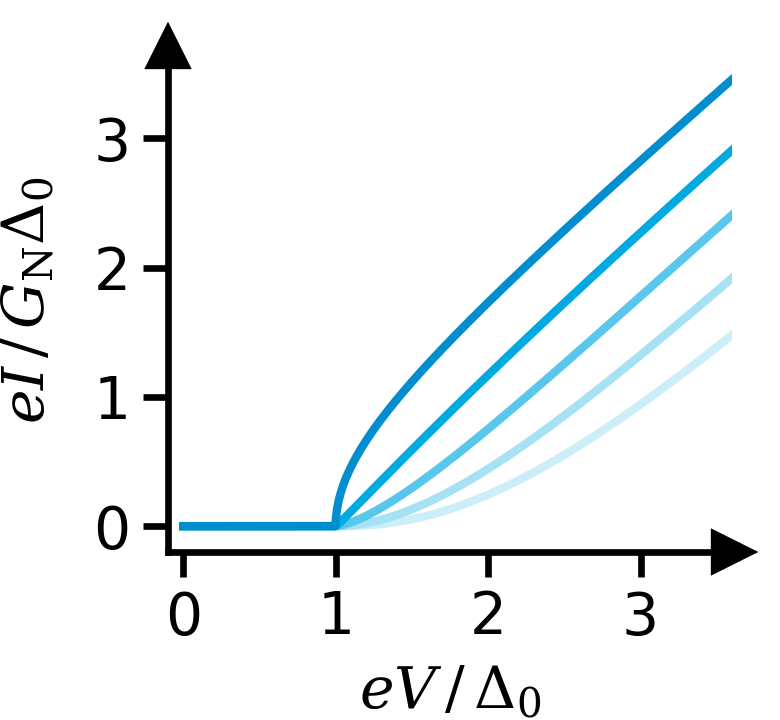

In [20]:
fig, ax = sc.get_figure(figsize=figsize)

for i, aq in enumerate(alphaq):
    ax.plot(
        V_Delta,
        Isinohm_nA[i, :] / (sc.G0_muS * Delta_meV),
        color=sc.seeblau[i],
        zorder=5 - i,
        label=f"{aq:1.2f}",
    )

ax.set_xlim(-0.1, 3.6)
ax.set_xticks([0, 1, 2, 3])

ax.set_ylim(-0.2, 3.7)
ax.set_yticks([0, 1, 2, 3])

xlabel = "$eV\\,/\\,\\Delta_0$"
ylabel = "$eI\\,/\\,G_\\mathrm{N}\\Delta_0$"
title = "theory/stochastic/dcb-ohm-iv-sin"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

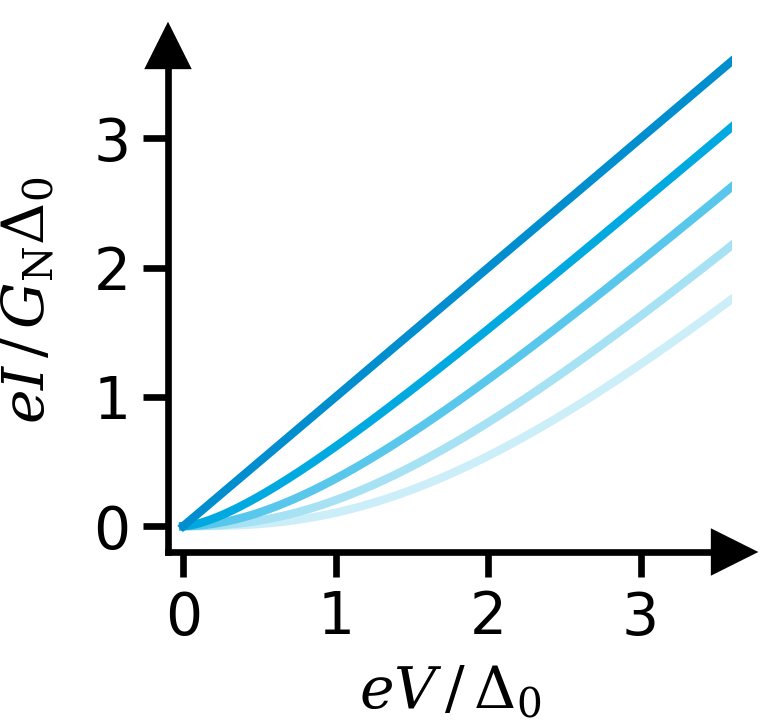

In [21]:
fig, ax = sc.get_figure(figsize=figsize)

for i, aq in enumerate(alphaq):
    ax.plot(
        V_Delta,
        Ininohm_nA[i, :] / (sc.G0_muS * Delta_meV),
        color=sc.seeblau[i],
        zorder=5 - i,
        label=f"{aq:1.2f}",
    )

ax.set_xlim(-0.1, 3.6)
ax.set_xticks([0, 1, 2, 3])

ax.set_ylim(-0.2, 3.7)
ax.set_yticks([0, 1, 2, 3])

xlabel = "$eV\\,/\\,\\Delta_0$"
ylabel = "$eI\\,/\\,G_\\mathrm{N}\\Delta_0$"
title = "theory/stochastic/dcb-ohm-iv-nin"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

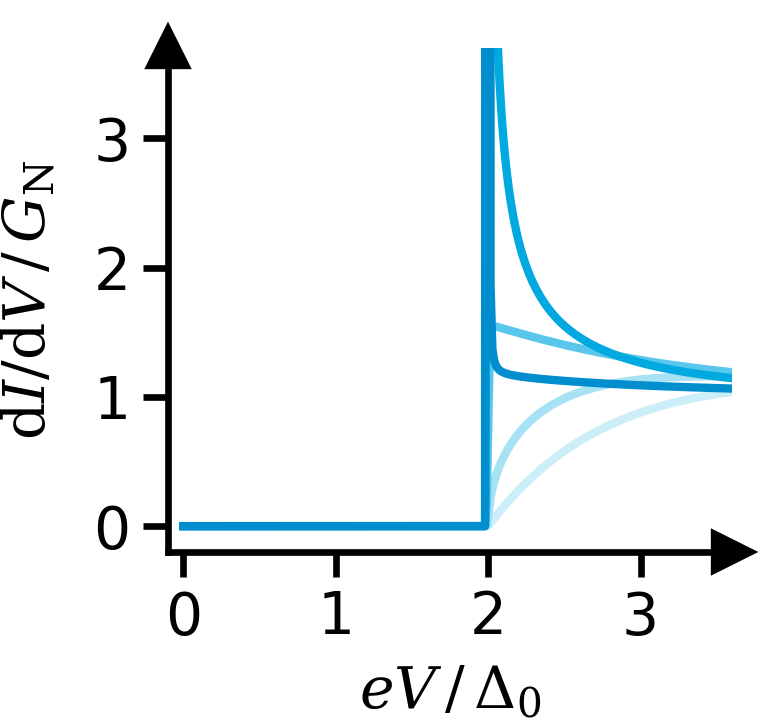

In [22]:
fig, ax = sc.get_figure(figsize=figsize)

for i, aq in enumerate(alphaq):
    ax.plot(
        V_Delta,
        dIdVsisohm[i, :],
        color=sc.seeblau[i],
        zorder=5 - i,
        label=f"{aq:1.2f}",
    )

ax.set_xlim(-0.1, 3.6)
ax.set_xticks([0, 1, 2, 3])

ax.set_ylim(-0.2, 3.7)
ax.set_yticks([0, 1, 2, 3])

xlabel = "$eV\\,/\\,\\Delta_0$"
ylabel = "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$"
title = "theory/stochastic/dcb-ohm-didv-sis"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

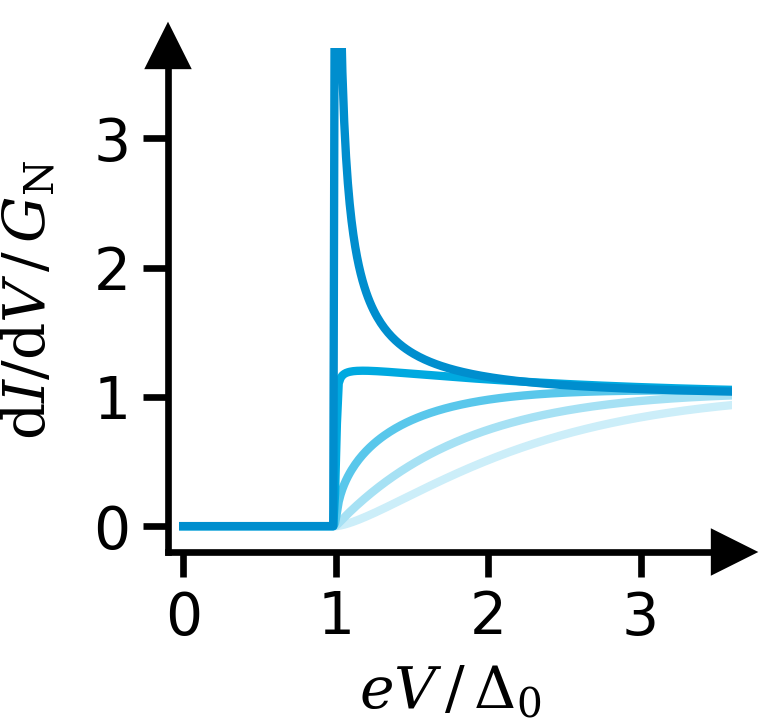

In [23]:
fig, ax = sc.get_figure(figsize=figsize)

for i, aq in enumerate(alphaq):
    ax.plot(
        V_Delta,
        dIdVsinohm[i, :],
        color=sc.seeblau[i],
        zorder=5 - i,
        label=f"{aq:1.2f}",
    )

ax.set_xlim(-0.1, 3.6)
ax.set_xticks([0, 1, 2, 3])

ax.set_ylim(-0.2, 3.7)
ax.set_yticks([0, 1, 2, 3])

xlabel = "$eV\\,/\\,\\Delta_0$"
ylabel = "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$"
title = "theory/stochastic/dcb-ohm-didv-sin"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

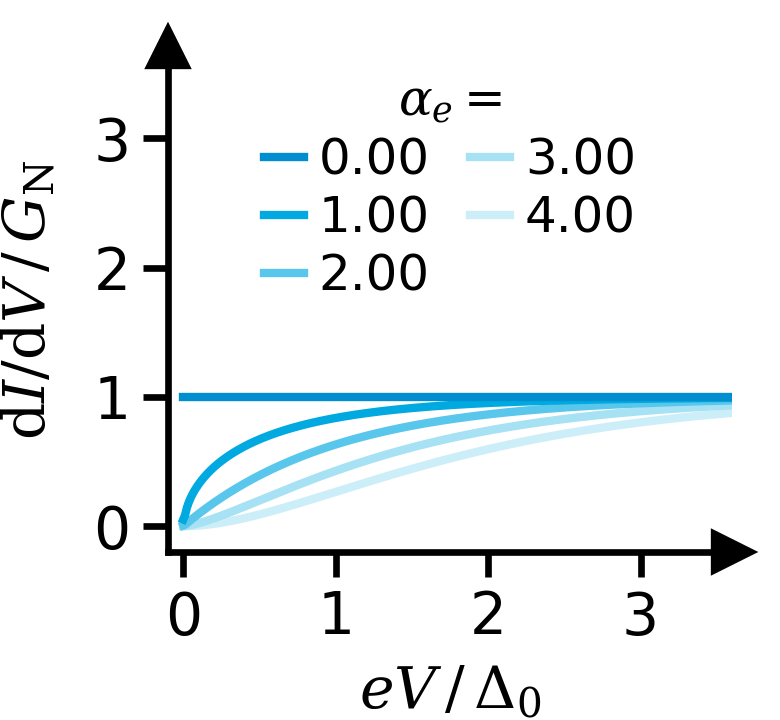

In [24]:
fig, ax = sc.get_figure(figsize=figsize)

for i, aq in enumerate(alphaq):
    ax.plot(
        V_Delta,
        dIdVninohm[i, :],
        color=sc.seeblau[i],
        zorder=5 - i,
        label=f"{aq:1.2f}",
    )


ax.legend(
    title="$\\alpha_e = $",
    handlelength=0.8,
    loc="upper center",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=2,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.2,  # reduces vertical spacing between items
    handletextpad=0.3,  # reduces spacing between line and label
    # bbox_to_anchor=(0.01, 1.1),
)

ax.set_xlim(-0.1, 3.6)
ax.set_xticks([0, 1, 2, 3])

ax.set_ylim(-0.2, 3.7)
ax.set_yticks([0, 1, 2, 3])

xlabel = "$eV\\,/\\,\\Delta_0$"
ylabel = "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$"
title = "theory/stochastic/dcb-ohm-didv-nin"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

# Resonant Environment & Photo-Assisted 

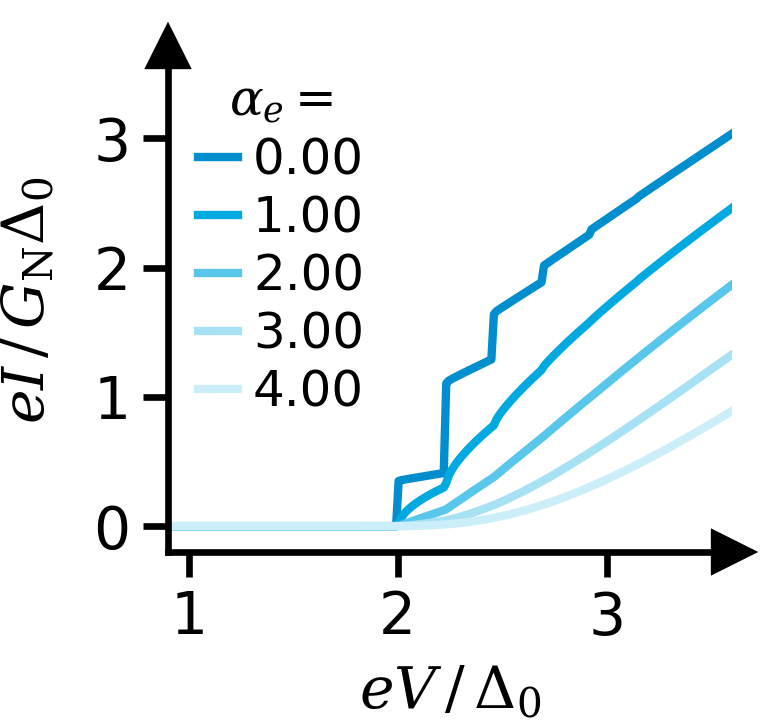

In [25]:
fig, ax = sc.get_figure(figsize=figsize)

for i, aq in enumerate(alphaq):
    ax.plot(
        V_Delta,
        Isisres_nA[i, :] / (GN_G0 * sc.G0_muS * Delta_meV),
        color=sc.seeblau[i],
        zorder=i - 5,
        label=f"{aq:1.2f}",
    )

ax.legend(
    title="$\\alpha_e = $",
    handlelength=0.8,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.2,  # reduces vertical spacing between items
    handletextpad=0.3,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)

ax.set_xlim(0.9, 3.6)
ax.set_xticks([1, 2, 3])

ax.set_ylim(-0.2, 3.7)
ax.set_yticks([0, 1, 2, 3])

xlabel = "$eV\\,/\\,\\Delta_0$"
ylabel = "$eI\\,/\\,G_\\mathrm{N}\\Delta_0$"
title = "theory/stochastic/dcb-res-iv-sis"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

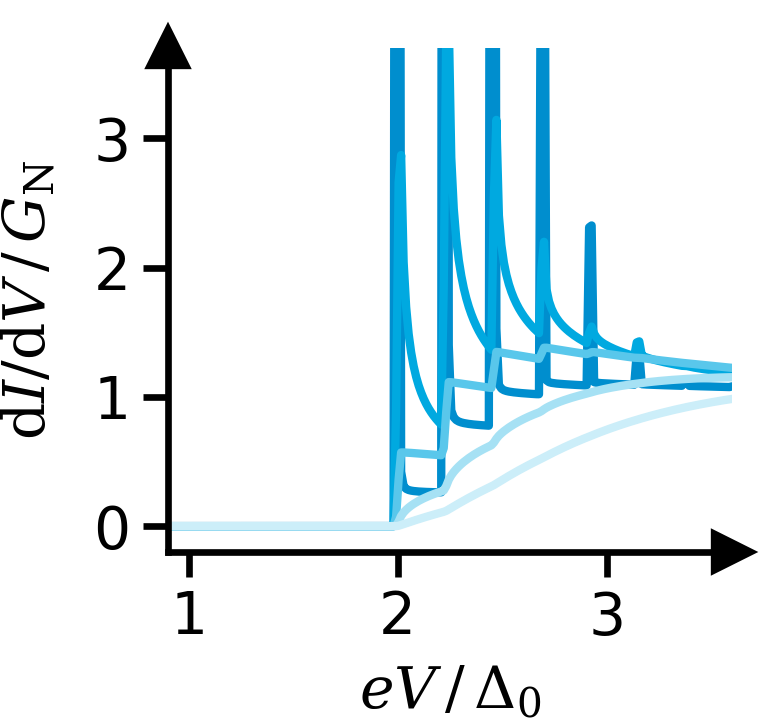

In [26]:
fig, ax = sc.get_figure(figsize=figsize)

for i, aq in enumerate(alphaq):
    ax.plot(
        V_Delta,
        dIdVsisres[i, :],
        color=sc.seeblau[i],
        zorder=i - 5,
        label=f"{aq:1.2f}",
    )

ax.set_xlim(0.9, 3.6)
ax.set_xticks([1, 2, 3])

ax.set_ylim(-0.2, 3.7)
ax.set_yticks([0, 1, 2, 3])

xlabel = "$eV\\,/\\,\\Delta_0$"
ylabel = "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$"
title = "theory/stochastic/dcb-res-didv-sis"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

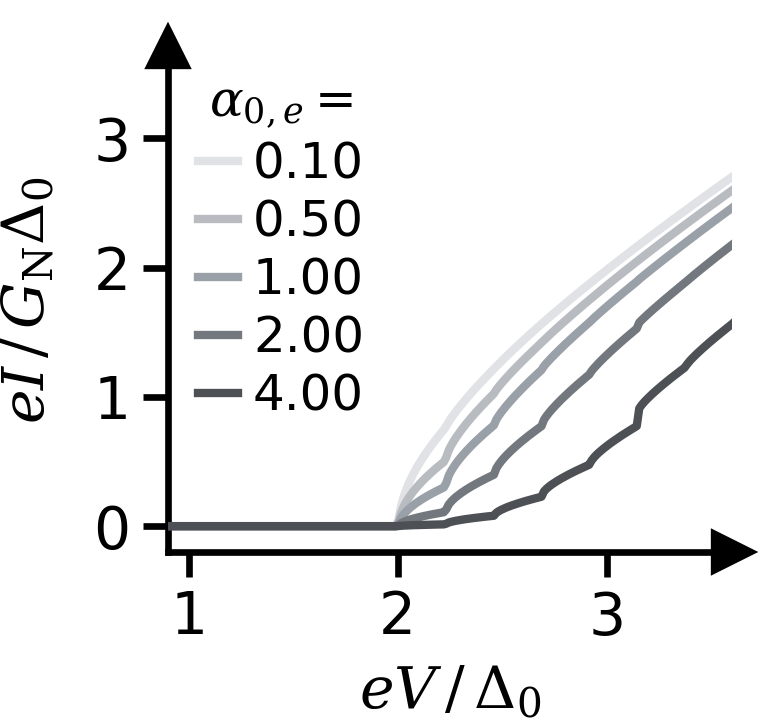

In [27]:
fig, ax = sc.get_figure(figsize=figsize)

for i, a0 in enumerate(alpha0):
    ax.plot(
        V_Delta,
        Isisresa_nA[i, :] / (GN_G0 * sc.G0_muS * Delta_meV),
        color=sc.seegrau[4 - i],
        zorder=i,
        label=f"{a0:1.2f}",
    )

ax.legend(
    title="$\\alpha_{0, e} = $",
    handlelength=0.8,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.2,  # reduces vertical spacing between items
    handletextpad=0.3,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)

ax.set_xlim(0.9, 3.6)
ax.set_xticks([1, 2, 3])

ax.set_ylim(-0.2, 3.7)
ax.set_yticks([0, 1, 2, 3])

xlabel = "$eV\\,/\\,\\Delta_0$"
ylabel = "$eI\\,/\\,G_\\mathrm{N}\\Delta_0$"
title = "theory/stochastic/dcb-resa-iv-sis"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

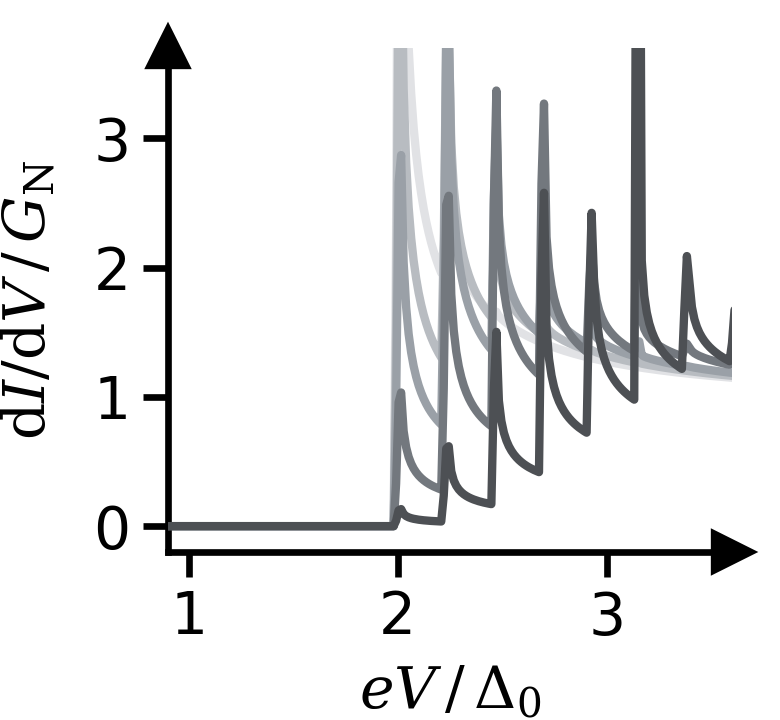

In [28]:
fig, ax = sc.get_figure(figsize=figsize)

for i, a0 in enumerate(alpha0):
    ax.plot(
        V_Delta,
        dIdVsisresa[i, :],
        color=sc.seegrau[4 - i],
        zorder=i,
        label=f"{a0:1.2f}",
    )

ax.set_xlim(0.9, 3.6)
ax.set_xticks([1, 2, 3])

ax.set_ylim(-0.2, 3.7)
ax.set_yticks([0, 1, 2, 3])

xlabel = "$eV\\,/\\,\\Delta_0$"
ylabel = "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$"
title = "theory/stochastic/dcb-resa-didv-sis"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

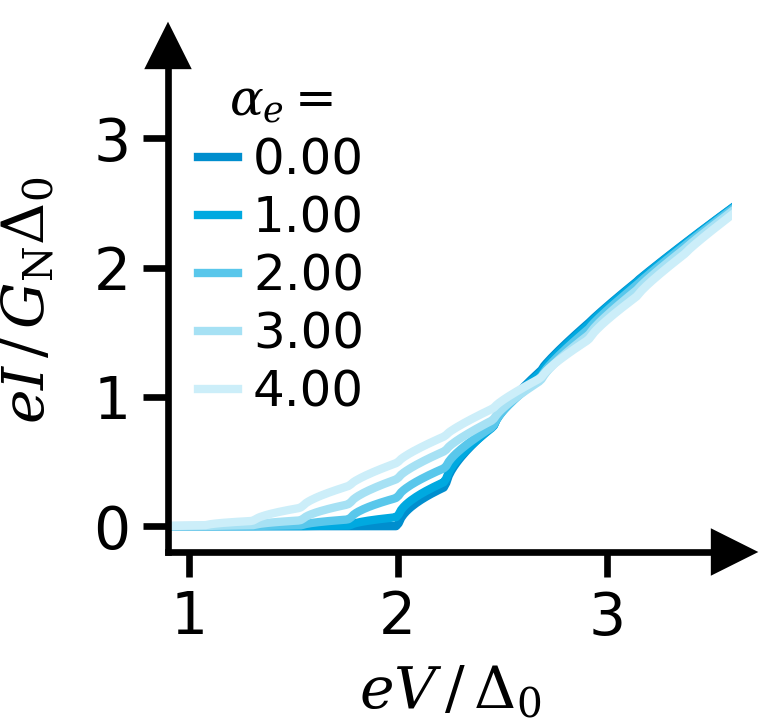

In [29]:
fig, ax = sc.get_figure(figsize=figsize)

for i, aq in enumerate(alphaq):
    ax.plot(
        V_Delta,
        Ipata_nA[i, :] / (GN_G0 * sc.G0_muS * Delta_meV),
        color=sc.seeblau[i],
        zorder=i - 5,
        label=f"{aq:1.2f}",
    )

ax.legend(
    title="$\\alpha_e = $",
    handlelength=0.8,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.2,  # reduces vertical spacing between items
    handletextpad=0.3,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)

ax.set_xlim(0.9, 3.6)
ax.set_xticks([1, 2, 3])

ax.set_ylim(-0.2, 3.7)
ax.set_yticks([0, 1, 2, 3])

xlabel = "$eV\\,/\\,\\Delta_0$"
ylabel = "$eI\\,/\\,G_\\mathrm{N}\\Delta_0$"
title = "theory/stochastic/dcb-pat-ohm-iv-sis"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

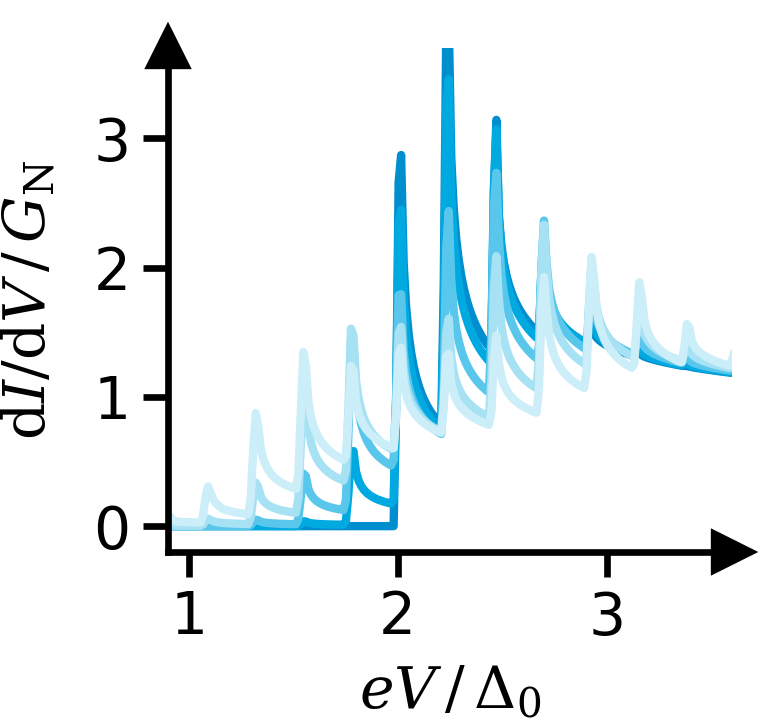

In [30]:
fig, ax = sc.get_figure(figsize=figsize)

for i, aq in enumerate(alphaq):
    ax.plot(
        V_Delta,
        dIdVpata[i, :],
        color=sc.seeblau[i],
        zorder=i - 5,
        label=f"{aq:1.2f}",
    )

ax.set_xlim(0.9, 3.6)
ax.set_xticks([1, 2, 3])

ax.set_ylim(-0.2, 3.7)
ax.set_yticks([0, 1, 2, 3])

xlabel = "$eV\\,/\\,\\Delta_0$"
ylabel = "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$"
title = "theory/stochastic/dcb-pat-ohm-didv-sis"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

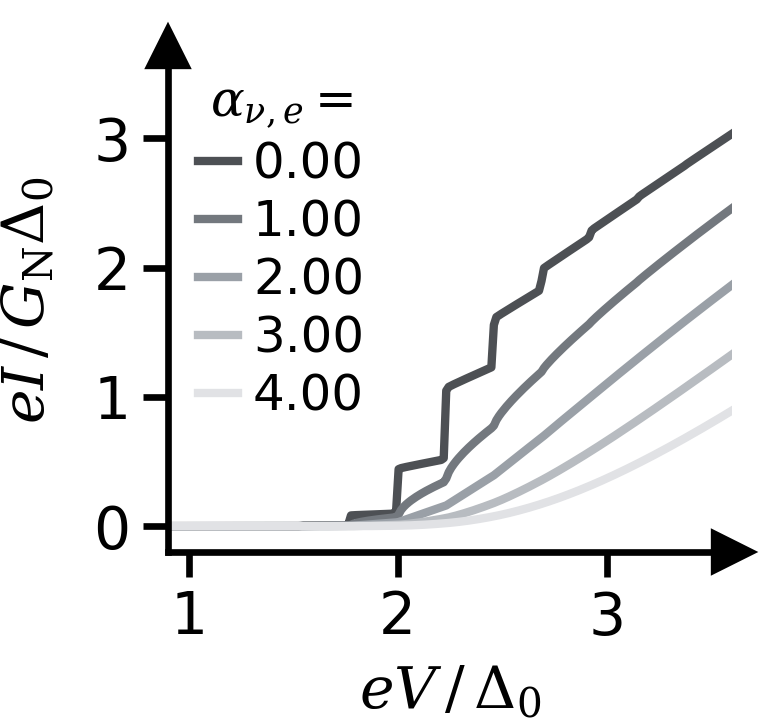

In [35]:
fig, ax = sc.get_figure(figsize=figsize)

for i, anu in enumerate(alphanu):
    ax.plot(
        V_Delta,
        Ipat_nA[i, :] / (GN_G0 * sc.G0_muS * Delta_meV),
        color=sc.seegrau[i],
        zorder=i - 5,
        label=f"{anu:1.2f}",
    )

ax.legend(
    title="$\\alpha_{\\nu, e} = $",
    handlelength=0.8,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.2,  # reduces vertical spacing between items
    handletextpad=0.3,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)

ax.set_xlim(0.9, 3.6)
ax.set_xticks([1, 2, 3])

ax.set_ylim(-0.2, 3.7)
ax.set_yticks([0, 1, 2, 3])

xlabel = "$eV\\,/\\,\\Delta_0$"
ylabel = "$eI\\,/\\,G_\\mathrm{N}\\Delta_0$"
title = "theory/stochastic/dcb-pata-ohm-iv-sis"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

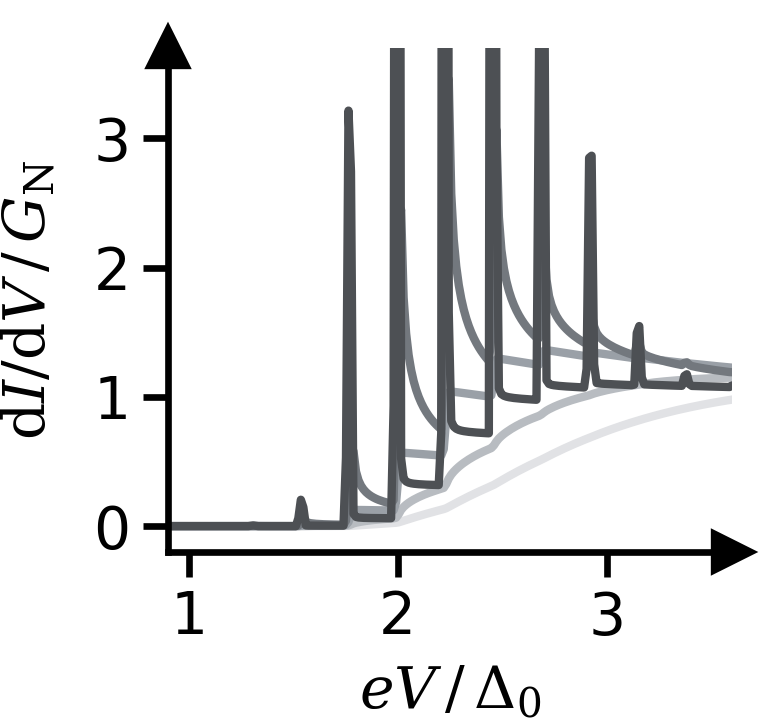

In [34]:
fig, ax = sc.get_figure(figsize=figsize)

for i, anu in enumerate(alphanu):
    ax.plot(
        V_Delta,
        dIdVpat[i, :],
        color=sc.seegrau[i],
        zorder=-i,
        label=f"{anu:1.2f}",
    )

ax.set_xlim(0.9, 3.6)
ax.set_xticks([1, 2, 3])

ax.set_ylim(-0.2, 3.7)
ax.set_yticks([0, 1, 2, 3])

xlabel = "$eV\\,/\\,\\Delta_0$"
ylabel = "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$"
title = "theory/stochastic/dcb-pata-ohm-didv-sis"

sc.theory_layout(fig, ax, title, xlabel, ylabel)